In [80]:
# BIBLIOTECAS UTILIZADAS

from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
from kneed import KneeLocator
from sklearn import metrics
from sklearn.cluster import KMeans

img_dir = Path('..') / 'report' / 'notebook_03' / 'img'
csv_dir = Path('..') / 'report' / 'notebook_03' / 'csv'
img_dir.mkdir(parents=True, exist_ok=True)
csv_dir.mkdir(parents=True, exist_ok=True)

In [81]:
# CARREGANDO O DATAFRAME

data_file = Path('..') / 'data' / 'data_processed' / 'SUPERSTORE_MODELAGEM.csv'
df = pd.read_csv(data_file, sep=',')

In [82]:
# SELEÇÃO DE VARIÁVEIS PARA CLUSTERIZAÇÃO

df_clustering = df[['ORDER_DATE', 'SHIP_MODE', 'CUSTOMER_ID', 'SEGMENT', 'CATEGORY', 'REGION', 'NET_SALES', 'PROFIT', 'NET_SALES_SCALED', 'PROFIT_SCALED']].copy()


# AGRUPAMENTO POR CLIENTE

df_clustering = df_clustering.groupby('CUSTOMER_ID', as_index=False).agg({
    'ORDER_DATE': 'first',
    'SHIP_MODE': 'first',
    'CATEGORY': 'first',
    'REGION': 'first',
    'SEGMENT': 'first',
    'NET_SALES': 'sum',
    'PROFIT': 'sum',
    'NET_SALES_SCALED': 'sum',
    'PROFIT_SCALED': 'sum'
})


In [83]:
# CRIAÇÃO DE X_SCALED PARA CLUSTERIZAÇÃO

X_scaled = df_clustering.drop(columns=['CUSTOMER_ID', 'NET_SALES', 'PROFIT'])
X_scaled['ORDER_DATE'] = pd.to_datetime(df_clustering['ORDER_DATE'], errors='coerce').dt.year

In [84]:
# VERIFICAÇÃO DE VARIÁVEIS CATEGÓRICAS

cols_one_hot = ['SHIP_MODE', 'SEGMENT', 'REGION', 'CATEGORY', 'ORDER_DATE']

for col in cols_one_hot:
    print(df_clustering[col].value_counts(), '\n')

SHIP_MODE
STANDARD CLASS    445
SECOND CLASS      162
FIRST CLASS       119
SAME DAY           44
Name: count, dtype: int64 

SEGMENT
CONSUMER       395
CORPORATE      229
HOME OFFICE    146
Name: count, dtype: int64 

REGION
WEST       284
EAST       210
CENTRAL    141
SOUTH      135
Name: count, dtype: int64 

CATEGORY
OFFICE SUPPLIES    512
FURNITURE          142
TECHNOLOGY         116
Name: count, dtype: int64 

ORDER_DATE
2019-11-01    6
2019-09-30    5
2019-04-05    5
2020-11-07    4
2019-07-14    4
             ..
2019-09-06    1
2021-01-07    1
2020-07-24    1
2022-05-11    1
2021-05-05    1
Name: count, Length: 515, dtype: int64 



In [85]:
# ONE-HOT ENCODING

X_scaled = pd.get_dummies(
    X_scaled,
    columns=cols_one_hot)

In [86]:
# DEFINIÇÃO DO NÚMERO DE CLUSTERS E AVALIAÇÃO DE MÉTRICAS

k_range = range(2, 8)

results = {
    'k': [],
    'inertia': [],
    'silhouette': [],
    'calinski_harabasz': [],
    'davies_bouldin': [],
}

for k in k_range:
    model = KMeans(n_clusters=k, 
        n_init=10,
        random_state=0,
        max_iter=200
    )
    labels = model.fit_predict(X_scaled)

    results['k'].append(k)
    results['inertia'].append(model.inertia_)
    results['silhouette'].append(
        metrics.silhouette_score(X_scaled, labels)
    )
    results['calinski_harabasz'].append(
        metrics.calinski_harabasz_score(X_scaled, labels)
    )
    results['davies_bouldin'].append(
        metrics.davies_bouldin_score(X_scaled, labels)
    )


df_metrics = pd.DataFrame(results).set_index('k')

knee = KneeLocator(
    x=df_metrics.index,
    y=df_metrics['inertia'],
    curve='convex',
    direction='decreasing'
)

k_optimal = knee.knee
if k_optimal is None:
    print('Elbow não encontrado')
    
k_sil = df_metrics['silhouette'].idxmax()
k_ch  = df_metrics['calinski_harabasz'].idxmax()
k_db  = df_metrics['davies_bouldin'].idxmin()

k_summary = pd.DataFrame({
    'method': ['silhouette', 'calinski_harabasz', 'davies_bouldin', 'elbow'],
    'k': [k_sil, k_ch, k_db, k_optimal]
})

k_summary.to_csv(csv_dir / 'k_summary.csv', index=False)
k_summary

Elbow não encontrado


,method,k
0,silhouette,3.0
1,calinski_harabasz,2.0
2,davies_bouldin,7.0
3,elbow,NaN


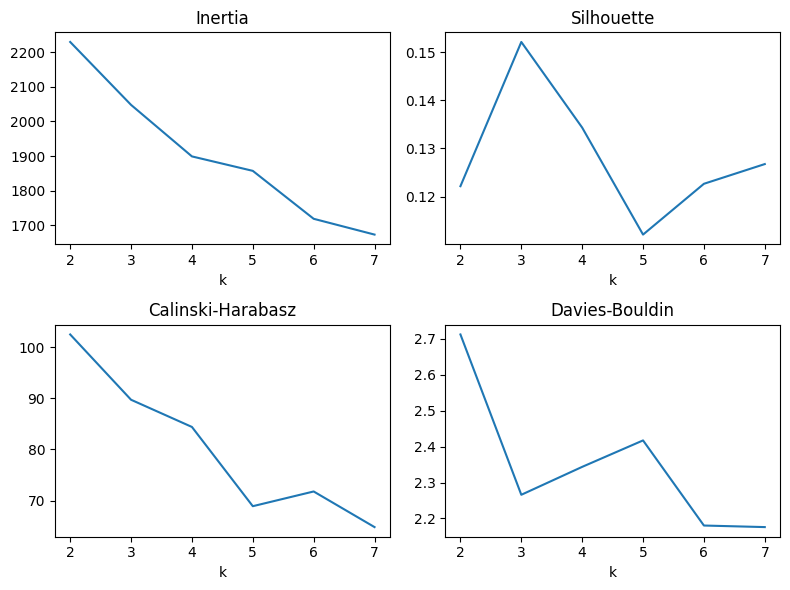

In [87]:
# APRESENTAÇÃO GRÁFICA DAS MÉTRICAS

fig, axes = plt.subplots(2, 2, figsize=(8, 6))

df_metrics['inertia'].plot(ax=axes[0, 0], title='Inertia')

if k_optimal is not None:
    axes[0, 0].axvline(k_optimal, linestyle='--')

df_metrics['silhouette'].plot(ax=axes[0, 1], title='Silhouette')
df_metrics['calinski_harabasz'].plot(ax=axes[1, 0], title='Calinski-Harabasz')
df_metrics['davies_bouldin'].plot(ax=axes[1, 1], title='Davies-Bouldin')

plt.tight_layout()
plt.savefig(img_dir / 'metricas_kmeans.png', dpi=150, bbox_inches='tight')
plt.show()

In [88]:
# APLICAÇÃO DO K-MEANS COM O NÚMERO DE CLUSTERS DEFINIDO

kmeans_publico = KMeans(n_clusters=3, 
        n_init=10,
        random_state=0
    )
kmeans_publico.fit(X_scaled)
labels = kmeans_publico.labels_

df_clustering['CLUSTER'] = labels


In [89]:
# ANÁLISE DOS CENTROIDES
centroids = pd.DataFrame(
    kmeans_publico.cluster_centers_,
    columns=X_scaled.columns
)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

centroids.round(2).to_csv(csv_dir / 'centroids.csv', index_label='CLUSTER')
display(centroids.round(2))

,NET_SALES_SCALED,PROFIT_SCALED,SHIP_MODE_FIRST CLASS,SHIP_MODE_SAME DAY,SHIP_MODE_SECOND CLASS,SHIP_MODE_STANDARD CLASS,SEGMENT_CONSUMER,SEGMENT_CORPORATE,SEGMENT_HOME OFFICE,REGION_CENTRAL,REGION_EAST,REGION_SOUTH,REGION_WEST,CATEGORY_FURNITURE,CATEGORY_OFFICE SUPPLIES,CATEGORY_TECHNOLOGY,ORDER_DATE_2019,ORDER_DATE_2020,ORDER_DATE_2021,ORDER_DATE_2022
0,-0.80,-0.26,0.14,0.07,0.25,0.55,1.0,0.0,-0.0,0.16,0.29,0.18,0.36,0.18,0.65,0.18,0.52,0.25,0.15,0.07
1,-0.81,-0.27,0.19,0.03,0.19,0.58,0.0,1.0,-0.0,0.20,0.26,0.20,0.34,0.19,0.68,0.13,0.51,0.28,0.16,0.05
2,-0.74,-0.24,0.14,0.05,0.14,0.66,0.0,0.0,1.0,0.21,0.25,0.11,0.42,0.19,0.70,0.11,0.46,0.29,0.18,0.08


In [90]:
# DEFINIÇÃO DA MÉDIA DE NET_SALES E PROFIT POR CLUSTER

resumo_clusters = (
    df_clustering
    .groupby('CLUSTER')
    .agg(
        qtd_clientes=('CUSTOMER_ID', 'count'),
        media_net_sales=('NET_SALES', 'mean'),
        media_profit=('PROFIT', 'mean')
    )
    .reset_index()
    .sort_values('CLUSTER')
    .reset_index(drop=True)
)

resumo_clusters.columns = [col.upper() for col in resumo_clusters.columns]

resumo_clusters.round(2).to_csv(csv_dir / 'resumo_clusters.csv', index=False)
display(resumo_clusters.round(2))

,CLUSTER,QTD_CLIENTES,MEDIA_NET_SALES,MEDIA_PROFIT
0,0,395,868.46,56.02
1,1,229,889.33,56.64
2,2,146,722.67,49.42


In [91]:
# HISTOGRAMA DE PROFIT POR CLUSTER

fig = px.histogram(
    df_clustering,
    x='ORDER_DATE',
    y='PROFIT',
    nbins=(2022-2019)*12,
    color=df_clustering['CLUSTER'].astype(str),
    title='Histograma de Lucro por Cluster ao Longo do Tempo'
)

fig.update_layout(
    xaxis_title='Data do Pedido',
    yaxis_title='Lucro'
)

fig.write_image(img_dir / 'histogram_profit_by_cluster.png')
fig.show()

In [92]:
# HISTOGRAMA DE NET_SALES POR CLUSTER

fig = px.histogram(
    df_clustering,
    x='ORDER_DATE',
    y='NET_SALES',
    nbins=(2022-2019)*12,
    color=df_clustering['CLUSTER'].astype(str),
    title='Histograma de vendas líquidas por Cluster ao Longo do Tempo',
)

fig.update_layout(
    xaxis_title='Data do Pedido',
    yaxis_title='Vendas Líquidas'
)

fig.write_image(img_dir / 'histogram_net_sales_by_cluster.png')
fig.show()